In [157]:
import math
import matplotlib.pyplot as plt
import numpy as np

# Micrograd from scracth
This notebook follows Andrej Karpathy's tutorial *Neural Networks: Zero to Hero* step by step to buid micrograd from scratch.

# 1.Value Class& Forward Pass


- First create a value class so that value objects can be handled in a convenient way
  - Actually, not just for convenience: want to record the CHILDREN and OPERATION of the value object so that GRADIENT can be calculated automatically in the gradient descent step later.
- Do Forward pass to calculate the output. 



In [164]:
# initialise the Value class
class Value:
    def __init__(self, data):
        self.data = data
    def __repr__(self):
        return f"Value({self.data})"

In [165]:
a = Value(3)
a 


Value(3)

In [168]:
# allow addition and multiplicatoin
class Value:
    def __init__(self, data):
        self.data = data
    def __repr__(self):
        return f"Value({self.data})"
    def __add__(self, other):
        out = Value(self.data + other.data)
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data) 
        return out


In [170]:
a = Value(-3)
b = Value(2)
c = a * b
d = Value(10) + c 
# This process of calculating the the value of a complicated maths expression from basic ones is forward pass. In actual forward pass in neuralnet we calculate value of loss function

In [171]:
# record the children and the operation that the children undergoes to get the value objects
class Value:
    def __init__(self, data, _children= (), _op = ''): # must give default value for children and op other wise a = Value(3) doesn't work
        self.data = data
        self._prev = set(_children) #children shouldn't repeat
        self._op = _op
    def __repr__(self):
        return f"Value({self.data})"
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*') 
        return out

In [172]:
a = Value(-3)
b = Value(2)
c = a * b
d = Value(10) + c 

print(d._prev)
print(c._op)

{Value(10), Value(-6)}
*


# 2.Visualisation using graphviz

In [173]:
# Visualisation using graphviz
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ data %.4f }" % (n.data, ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

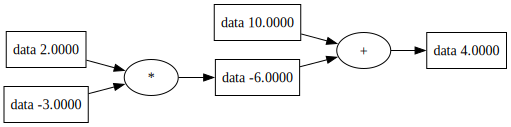

In [174]:
draw_dot(d)

In [175]:
# to visualise the node on the graph, add label 
class Value:
    def __init__(self, data, _children= (), _op = '', label = ''): # must give default value for children and op other wise a = Value(3) doesn't work
        self.data = data
        self._prev = set(_children) #children shouldn't repeat
        self._op = _op
        self.label = label # <- CHANGE
    def __repr__(self):
        return f"Value({self.data})"
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*') 
        return out

In [176]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2, label = 'f')
L = d * f; L.label = 'L'

In [177]:
# also modify the visualisation code to include the label
def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f }" % (n.label, n.data), shape='record') # <- CHANGE
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

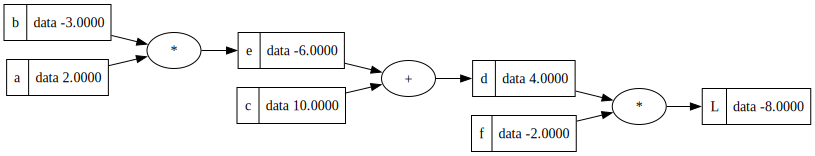

In [178]:
draw_dot(L)

# 3. Input x, Weight w, and Activation Function 


In [180]:
# add activation function to the class
class Value:
    def __init__(self, data, _children= (), _op = '', label = ''): # must give default value for children and op other wise a = Value(3) doesn't work
        self.data = data
        self._prev = set(_children) #children shouldn't repeat
        self._op = _op
        self.label = label 
    def __repr__(self):
        return f"Value({self.data})"
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*') 
        return out
    def tanh(self):# <- CHANGE
        x = self.data
        t = (math.exp(x)- math.exp(-x))/(math.exp(x)+math.exp(-x))
        out = Value(t, (self, ),'tanh') 
        return out


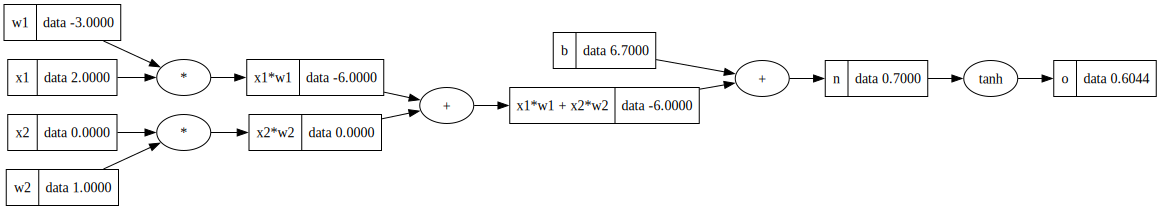

In [181]:
# First, use standard variables for a neuron input
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.7, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

# activation function & output
o = n.tanh(); o.label = 'o'
draw_dot(o)

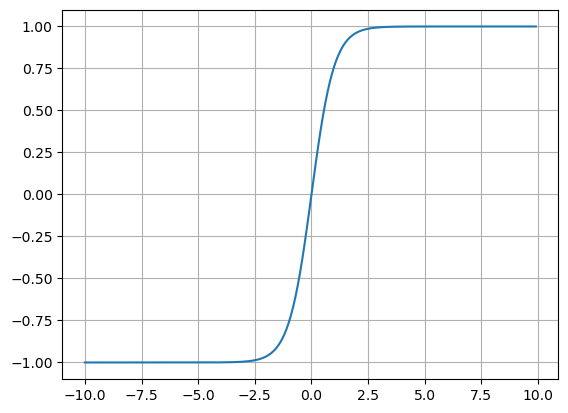

In [182]:
# Aside: activation function, here its tanh 
x = np.arange(-10,10, 0.1)
y = np.tanh(x)
plt.plot(x,y)
plt.grid()

# 4. Back Propagation
$\frac{d L}{d x} = \frac{d L}{d v} \frac{d v}{d x}$

In [205]:
class Value:
    def __init__(self, data, _children= (), _op = '', label = ''): # must give default value for children and op other wise a = Value(3) doesn't work
        self.data = data
        self._prev = set(_children) #children shouldn't repeat
        self._op = _op
        self.label = label 
        self._backward = lambda: None # <- CHANGE: initialise the _backward method to an empty function
        self.grad = 0 # <-CHANGE: initialise the grad for all values to be zero.
    def __repr__(self):
        return f"Value({self.data})"
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad * 1 # <- CHANGE: for add, dv/dself = 1. same for dother
            other.grad += out.grad * 1
        out._backward = _backward
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*') 
        def _backward():
            self.grad += out.grad * other.data # <- CHANGE: for mul, dv/dself = other. similar for dother
            other.grad += out.grad * self.data
        out._backward = _backward
        return out
    def tanh(self):
        x = self.data
        t = (math.exp(x)- math.exp(-x))/(math.exp(x)+math.exp(-x))
        out = Value(t, (self, ),'tanh') 
        def _backward():
            self.grad = out.grad * (1- t**2) 
        out._backward = _backward
        return out

In [206]:
# also modify the visualisation code to include the grad 
def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record') # <- CHANGE
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [207]:
# need to rerun the def of values as the class is modified
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432,label = 'b')
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

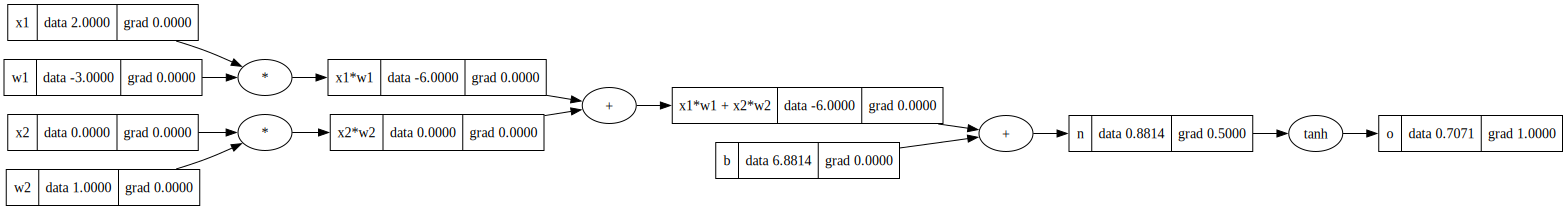

In [208]:
# Initialise the grad of o to be 1; Start back propagation!
o.grad = 1
o._backward()
draw_dot(o)

In [209]:
# Now only one backward step. For whole propagration require a loop, using topological sort

topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v) # do not append the element until all the children are appended; first append occurs when a value with no children is reached
    return topo

build_topo(o)

[Value(6.881373587019543),
 Value(0.0),
 Value(1.0),
 Value(0.0),
 Value(2.0),
 Value(-3.0),
 Value(-6.0),
 Value(-6.0),
 Value(0.8813735870195432),
 Value(0.7071067811865477)]

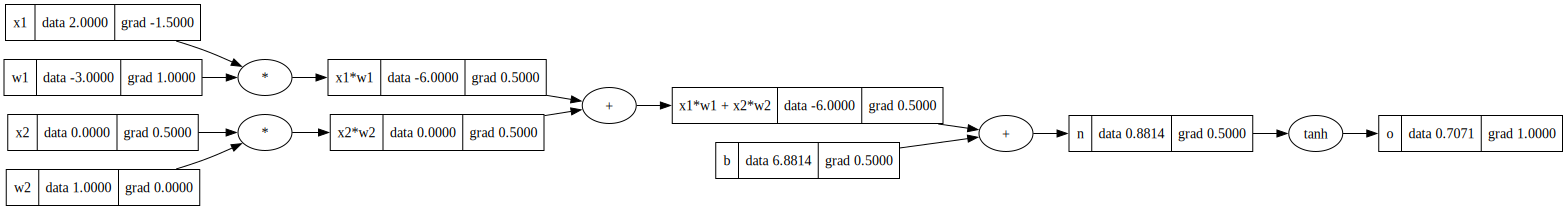

In [210]:
# Actually reversed topo list is required as we do back propagation "backwards"
o.grad = 1.0
for v in reversed(topo):
    v._backward()
draw_dot(o)

In [211]:
# It works! now hide the backward() inside the class
class Value:
    def __init__(self, data, _children= (), _op = '', label = ''): # must give default value for children and op other wise a = Value(3) doesn't work
        self.data = data
        self._prev = set(_children) #children shouldn't repeat
        self._op = _op
        self.label = label 
        self._backward = lambda: None # <- CHANGE
        self.grad = 0 # <-CHANGE: initialise the grad for all values to be zero.
    def __repr__(self):
        return f"Value({self.data})"
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad * 1 # <- CHANGE: for add, dv/dself = 1. same for dother
            other.grad += out.grad * 1
        out._backward = _backward
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*') 
        def _backward():
            self.grad += out.grad * other.data # <- CHANGE: for mul, dv/dself = other. similar for dother
            other.grad += out.grad * self.data
        out._backward = _backward
        return out
    def tanh(self):
        x = self.data
        t = (math.exp(x)- math.exp(-x))/(math.exp(x)+math.exp(-x))
        out = Value(t, (self, ),'tanh') 
        def _backward():
            self.grad = out.grad * (1- t**2) 
        out._backward = _backward
        return out

    def backward(self):
        # build topological sort list first
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
            return topo
        build_topo(self)
        # initialise the gradient 
        self.grad = 1
        # loop through all node in topo order
        for v in reversed(topo):
            v._backward()

In [212]:
# need to rerun the def of values as the class is modified
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432,label = 'b')
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

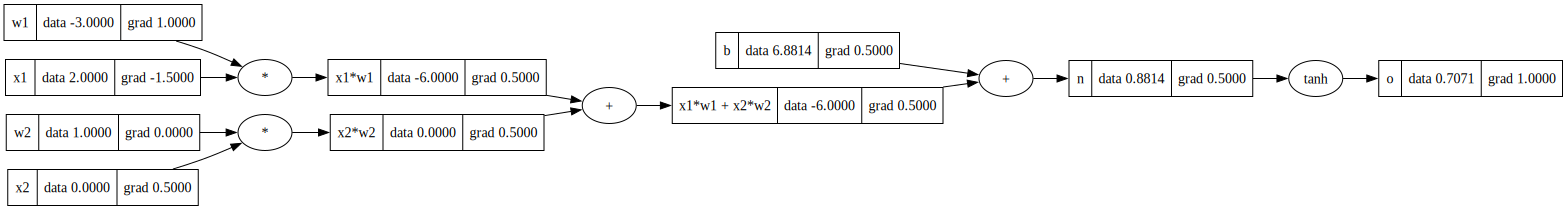

In [213]:
o.grad = 1
o.backward()
draw_dot(o)

# 5.More Operations

In [214]:
#currently this doesn't work
# Value(3) + 1

In [215]:
class Value:
    def __init__(self, data, _children= (), _op = '', label = ''): # must give default value for children and op other wise a = Value(3) doesn't work
        self.data = data
        self._prev = set(_children) #children shouldn't repeat
        self._op = _op
        self.label = label 
        self._backward = lambda: None 
        self.grad = 0 
    def __repr__(self):
        return f"Value({self.data})"
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # <- CHANGE
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad * 1 
            other.grad += out.grad * 1
        out._backward = _backward
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # <- CHANGE
        out = Value(self.data * other.data, (self, other), '*') 
        def _backward():
            self.grad += out.grad * other.data 
            other.grad += out.grad * self.data
        out._backward = _backward
        return out
    def tanh(self):
        x = self.data
        t = (math.exp(x)- math.exp(-x))/(math.exp(x)+math.exp(-x))
        out = Value(t, (self, ),'tanh') 
        def _backward():
            self.grad = out.grad * (1- t**2) 
        out._backward = _backward
        return out

    def backward(self):
        # build topological sort list first
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
            return topo
        build_topo(self)
        # initialise the gradient 
        self.grad = 1
        # loop through all node in topo order
        for v in reversed(topo):
            v._backward()

In [216]:
a = Value(3)
print(a * 3)
# but this doesn't work
# 3 * a

Value(9)


In [219]:
# include __rmul__
class Value:
    def __init__(self, data, _children= (), _op = '', label = ''): # must give default value for children and op other wise a = Value(3) doesn't work
        self.data = data
        self._prev = set(_children) #children shouldn't repeat
        self._op = _op
        self.label = label 
        self._backward = lambda: None 
        self.grad = 0 
    def __repr__(self):
        return f"Value({self.data})"
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) 
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad * 1 
            other.grad += out.grad * 1
        out._backward = _backward
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) 
        out = Value(self.data * other.data, (self, other), '*') 
        def _backward():
            self.grad += out.grad * other.data 
            other.grad += out.grad * self.data
        out._backward = _backward
        return out

    def __rmul__(self, other): # <- CHANGE
        return self * other

    def __radd__(self, other): # <- CHANGE: add this, same reason as rmul. useful when doing sum()
        return self + other 
    
    def tanh(self):
        x = self.data
        t = (math.exp(x)- math.exp(-x))/(math.exp(x)+math.exp(-x))
        out = Value(t, (self, ),'tanh') 
        def _backward():
            self.grad = out.grad * (1- t**2) 
        out._backward = _backward
        return out

    def backward(self):
        # build topological sort list first
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
            return topo
        build_topo(self)
        # initialise the gradient 
        self.grad = 1
        # loop through all node in topo order
        for v in reversed(topo):
            v._backward()

In [220]:
# now it works
a = Value(3)
3 * a

Value(9)

In [221]:
# include negative, subtraction, power, division, and exponentiation
class Value:
    def __init__(self, data, _children= (), _op = '', label = ''): # must give default value for children and op other wise a = Value(3) doesn't work
        self.data = data
        self._prev = set(_children) #children shouldn't repeat
        self._op = _op
        self.label = label 
        self._backward = lambda: None 
        self.grad = 0 
    def __repr__(self):
        return f"Value({self.data})"
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) 
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad * 1 
            other.grad += out.grad * 1
        out._backward = _backward
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) 
        out = Value(self.data * other.data, (self, other), '*') 
        def _backward():
            self.grad += out.grad * other.data 
            other.grad += out.grad * self.data
        out._backward = _backward
        return out

    def __rmul__(self, other): 
        return self * other

    def __radd__(self, other): 
        return self + other 
    
    def __neg__(self):
        return self * (-1)
    
    def __sub__(self, other):
        return self + (- other) # neg and sub don't need _back beacuse they rely on addition
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), 'Only integer or float indices are allowed'
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            self.grad += out.grad * other * self.data ** (other -1) 
        out._backward = _backward
        return out

    def __truediv__(self, other):
        out = self * other ** -1 # no _bacl as rely on pow
        return out 
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.grad *out.data
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(x)- math.exp(-x))/(math.exp(x)+math.exp(-x))
        out = Value(t, (self, ),'tanh') 
        def _backward():
            self.grad += out.grad * (1- t**2) 
        out._backward = _backward
        return out


    def backward(self):
        # build topological sort list first
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
            return topo
        build_topo(self)
        # initialise the gradient 
        self.grad = 1
        # loop through all node in topo order
        for v in reversed(topo):
            v._backward()

In [222]:
a = Value(3)
b = Value(2)
print(a -b)
print(a / b)
print(a**3) 

Value(1)
Value(1.5)
Value(27)


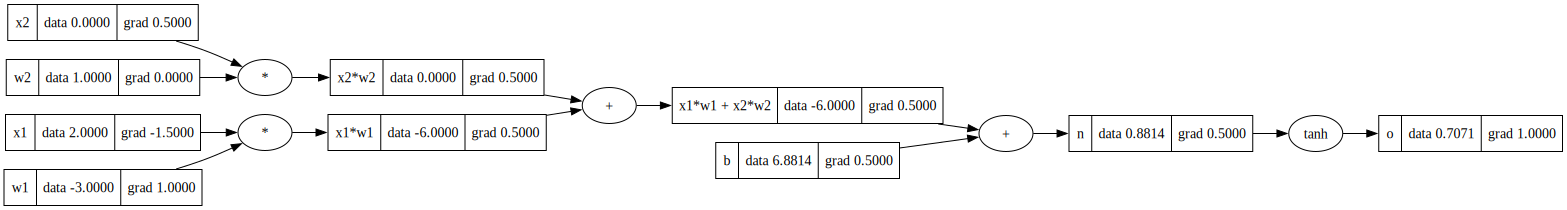

In [223]:
# With these new operations, we can decompose the tanh which uses math lib before. 
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432,label = 'b')
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.grad = 1
o.backward()
draw_dot(o)

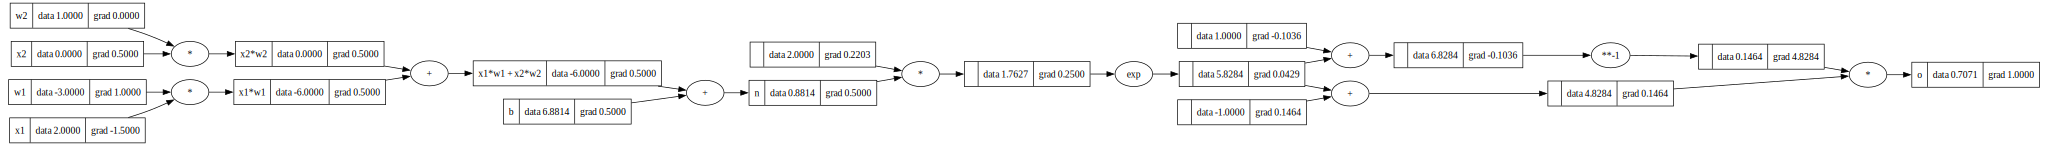

In [224]:
# modify tanh
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432,label = 'b')
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (2*n).exp() # tanhx = e**x - e**-x/e**x + e**-x = e**2x- 1/e**2x +1
o = (e -1) /(e +1)
o.label = 'o'
o.grad = 1
o.backward()
draw_dot(o)

# 6. Doing the same thing in Pytorch

In [ ]:
import torch

x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True #.double() used to turn float32 to float64
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


# 7. Building Neural Network
!!! keep in mind the following visuals.
- Neuron: circle
- Layer: a pair of 2 adjacent column of circles (in -> out)
- MLP: the ordered collection of layers
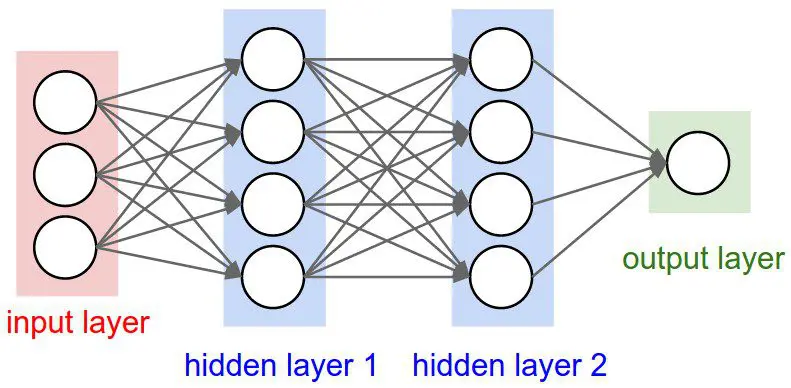

In [232]:
# This empty block is for revision use

In [233]:
# 1. Neuron 
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1))for _ in range(nin) ]# so if x = [x1, x2], w = [w1, w2]
        self.b = Value(random.uniform(-1,1)) # why not just random.uniform(-1,1)? because we want to record gradient! a number cannot do that!
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(x,self.w,)), self.b) # a = w dot x + b. if self.b not included, then __radd__ is required to be defined
        out = act.tanh()
        return out # just a Value

In [234]:
# Usage 

# input
x = [1.0, 2.0]
n = Neuron(2)
n(x)

Value(-0.19809910743999495)

In [235]:
# 2. Layer
# shape: [nin, nout], a layer is 2 columns
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons] 
        return outs[0] if len(outs) == 1 else outs # a column of Values

In [236]:
# Usage
x = [1.0,2.0]
n = Layer(2, 3)
n(x)

[Value(-0.3289726464539263),
 Value(0.9539594563331554),
 Value(-0.3009009400155062)]

In [237]:
# 3. MLP
class MLP:
    def __init__(self, nin, nouts): # outs, not out! e.g. nin = 3, nouts = [4,4,1]
        sz = [nin] + nouts # [3] + [4,4,1] = [3,4,4,1]
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(sz)-1)]
    def __call__(self,x):
        for layer in self.layers:
            x = layer(x) # Clever! So the out put of one layer is input for the next layer, sequentially
        # out = [layer(x) for layer in self.layers] THis is wrong
        return x

In [238]:
# Usage
x = [2,3,1]
n = MLP(3, [4,4,1])
n(x)

Value(-0.6129158571598518)

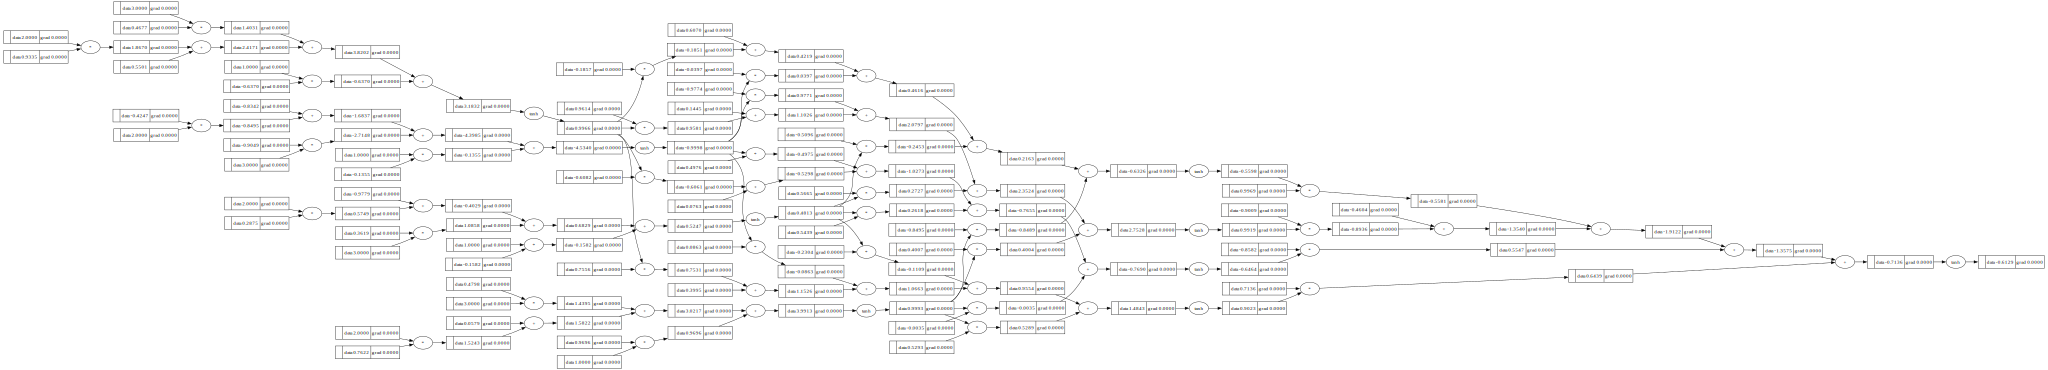

In [239]:
draw_dot(n(x))

# 8. Back Propagation for Neural Net


In [241]:
# Training set. 4 set of inputs each with size 3
xs = [
    [2.0,  3.0, -1.0],   # example 1
    [3.0, -1.0,  0.5],   # example 2
    [0.5,  1.0,  1.0],   # example 3
    [1.0,  1.0, -1.0],   # example 4
]

# target output for each of the training input set 
ys = [
    1.0,
    -1.0,
    -1.0,
    1.0,
]
# or more compactly

ys = [1.0, -1.0, -1.0, 1.0]


In [242]:
# predicted output with current neuralnet
ypred = [n(x) for x in xs]
ypred

[Value(-0.682385793348027),
 Value(-0.05854094937877402),
 Value(0.014000508901752454),
 Value(0.22789141510492641)]

In [244]:
# which is not close to ys. 
# want ypred = ys
# quantify how close we are using loss
# consider the list of differences from the target values
[(yout - ygt) for yout, ygt in zip(ypred,ys)] # ygt stand for y ground truth
# square so all positive
[(yout - ygt)**2 for yout, ygt in zip(ypred,ys)]
# define loss as the sum
loss = sum([(yout - ygt)**2 for yout, ygt in zip(ypred,ys)])
loss

Value(5.341115800577576)

In [245]:
# now do back propagation!
loss.backward()
# and see the result for a specific neuron's weight
n.layers[0].neurons[0].w[0].grad

-0.0020936053893126374

In [262]:
# need to collect all the parameters into a long list to train
# 1. Neuron 
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1))for _ in range(nin) ]# so if x = [x1, x2], w = [w1, w2]
        self.b = Value(random.uniform(-1,1))
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(x,self.w,)), self.b) # a = w dot x + b. if self.b not included, then __radd__ is required to be defined
        out = act.tanh()
        return out # just a Value
    def parameters(self): # <- CHANGE
        return self.w + [self.b] # simply get b into the list

# 2. Layer
# shape: [nin, nout], a layer is 2 colums
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons] 
        return outs[0] if len(outs) == 1 else outs # a column of Values
    def parameters(self): # <- CHANGE
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
# 3. MLP
class MLP:
    def __init__(self, nin, nouts): # outs, not out! e.g. nin = 3, nouts = [4,4,1]
        sz = [nin] + nouts # [3] + [4,4,1] = [3,4,4,1]
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(sz)-1)]
    def __call__(self,x):
        for layer in self.layers:
            x = layer(x) # Clever! So the out put of one layer is input for the next layer, sequentially
        return x
    def parameters(self): # <- CHANGE
        return [p for layer in self.layers for p in layer.parameters()]

In [263]:
# reconstruct n
n = MLP(3, [4,4,1])
# show all params
len(n.parameters())

41

# 9. Gradient Descent for Neural Net
loop of 
- 1. Forward Pass(calculate loss using new values)
- 2. Backward Pass(calculate new gradient using new values)
- 3. Update(calculate new values using new gradient)


In [264]:
# 1.Forward Pass 
ypred = [n(x) for x in xs]
loss = sum([(yout - ygt)**2 for yout, ygt in zip(ypred,ys)])

In [265]:
# 2.Backward Pass
# NEED TO ZERO THE GRAD FIRST!
for p in n.parameters():
    p.grad = 0
loss.backward()

In [266]:
# 3.Update (of value)
for p in n.parameters():
    lr = 0.01 # learning rate
    p.data += - lr * p.grad

In [267]:
# loop...

In [268]:
# As we loop through the 3 cells above, we get loss smaller and smaller, ypred closer and closer to ys [1,-1,-1,1]
print(loss)
print(ypred)

Value(6.8623917194857365)
[Value(-0.8329567532297547), Value(-0.6755304594280124), Value(-0.648855735350315), Value(-0.8094414836959519)]


In [274]:
# automatic loop 
for k in range(10):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt)**2 for yout, ygt in zip(ypred,ys)])
    # 2.Backward Pass
    for p in n.parameters():
        p.grad = 0
    loss.backward()
    # 3.Update (of value)
    for p in n.parameters():
        lr = 0.01 # learning rate
        p.data += - lr * p.grad
    print(k, loss.data, ypred)

0 0.9615126787790084 [Value(0.48024084687206436), Value(-0.5618468700963184), Value(-0.4971203035493544), Value(0.5035154109420379)]
1 0.8970345624089642 [Value(0.49865158336298604), Value(-0.5756233116070917), Value(-0.5148682933767507), Value(0.5201708834157672)]
2 0.8381426759856331 [Value(0.5160868800234893), Value(-0.5886588493737531), Value(-0.5316056932791781), Value(0.5359138016130751)]
3 0.784376788823868 [Value(0.5325696320140008), Value(-0.6009881761080709), Value(-0.5473726893616137), Value(0.5507743084294496)]
4 0.7352884748550526 [Value(0.5481329676523211), Value(-0.6126474233347433), Value(-0.5622158422496243), Value(0.5647900822523286)]
5 0.690450838641582 [Value(0.5628168825462786), Value(-0.6236732554400871), Value(-0.5761853292086073), Value(0.5780034755996809)]
6 0.649464388474108 [Value(0.5766655560324918), Value(-0.6341021528331369), Value(-0.5893328471445956), Value(0.5904592913651691)]
7 0.6119600379288828 [Value(0.5897252796616036), Value(-0.6439698625926237), 

In [ ]:
# Done!